In [1]:
# =============================================================
# PART 1: NEURAL NETWORK FUNDAMENTALS AND TRAINING BEHAVIOR
# TASK 1: DATASET UNDERSTANDING
# =============================================================

# First, let's import the libraries we'll need
import pandas as pd
import numpy as np

In [2]:
# --- Step 1: Load the Dataset ---
df = pd.read_csv('customer_churn_nn.csv')

# Let's take a quick peek at what we're working with
print("First 5 rows of the dataset:")
print(df.head())


# --- Step 2: Number of Rows and Columns ---
print(f"Dataset Shape: {df.shape}")
print(f"Number of Rows (samples): {df.shape[0]}")
print(f"Number of Columns (features + target): {df.shape[1]}")

First 5 rows of the dataset:
  customer_id   region plan_type   contract_type payment_method  \
0    CUST0001    South  Standard  Month-to-month     Debit Card   
1    CUST0002     West   Premium  Month-to-month         Wallet   
2    CUST0003  Central  Standard  Month-to-month    Credit Card   
3    CUST0004     West   Premium  Month-to-month    Credit Card   
4    CUST0005    North   Premium  Month-to-month    Net Banking   

   tenure_months  monthly_charges_inr  avg_login_days_per_month  \
0             30               687.40                        13   
1             15              1029.74                        22   
2             72               732.07                        13   
3             22               959.51                        19   
4             11               890.20                        18   

   support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
0                             0                   0          87.97   
1                        

In [3]:
# --- Step 3: Type of Input Features ---
print("Data Types of Each Column:")
print(df.dtypes)

# Let's separate them clearly
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"--- Categorical Features ({len(categorical_cols)}) ---")
for col in categorical_cols:
    print(f"  • {col} → {df[col].nunique()} unique values: {list(df[col].unique())}")

print(f"--- Numerical Features ({len(numerical_cols)}) ---")
for col in numerical_cols:
    print(f"  • {col} (dtype: {df[col].dtype})")


Data Types of Each Column:
customer_id                         str
region                              str
plan_type                           str
contract_type                       str
payment_method                      str
tenure_months                     int64
monthly_charges_inr             float64
avg_login_days_per_month          int64
support_tickets_last_90_days      int64
payment_delay_days                int64
data_usage_gb                   float64
satisfaction_score              float64
last_complaint_days_ago           int64
discount_percent                  int64
autopay_enabled                   int64
referral_count                    int64
churn                             int64
dtype: object
--- Categorical Features (5) ---
  • customer_id → 2000 unique values: ['CUST0001', 'CUST0002', 'CUST0003', 'CUST0004', 'CUST0005', 'CUST0006', 'CUST0007', 'CUST0008', 'CUST0009', 'CUST0010', 'CUST0011', 'CUST0012', 'CUST0013', 'CUST0014', 'CUST0015', 'CUST0016', 'CUST0017', 'CU

C:\Users\vobalap\AppData\Local\Temp\ipykernel_7696\1829359085.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns.tolist()


In [6]:
# --- Step 4: Target Variable Description ---
print("" + "="*50)
print("TARGET VARIABLE: 'churn'")
print("="*50)
print("""
• Column Name: churn
• Type: Binary (Integer - 0 or 1)
• Meaning:
    - 0 → Customer was RETAINED (did not leave)
    - 1 → Customer CHURNED (left the service)
• This is a CLASSIFICATION problem (binary classification)
""")
# --- Step 5: Missing Value Check ---
print("--- Missing Value Check ---")
missing = df.isnull().sum()
print(missing)
print(f"Total missing values in entire dataset: {df.isnull().sum().sum()}")


TARGET VARIABLE: 'churn'

• Column Name: churn
• Type: Binary (Integer - 0 or 1)
• Meaning:
    - 0 → Customer was RETAINED (did not leave)
    - 1 → Customer CHURNED (left the service)
• This is a CLASSIFICATION problem (binary classification)

--- Missing Value Check ---
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64
Total missing values in entire dataset: 0


In [7]:
# --- Step 6: Basic Statistical Summary ---
print("--- Statistical Summary (Numerical Features) ---")
print(df.describe())

# EXPECTED OUTPUT (key observations):
# tenure_months: mean=25.36, ranges from 1 to 72 months
# monthly_charges_inr: mean=₹766.49, ranges from ₹255.45 to ₹2156.52
# satisfaction_score: mean=6.87, ranges from 1.0 to 10.0
# payment_delay_days: mean=3.56, ranges from 0 to 31 days
# data_usage_gb: mean=90.01 GB, ranges from 0.5 to 265.51 GB


# --- Step 7: Distribution of the Target Variable ---
print("--- Target Variable Distribution ---")
churn_dist = df['churn'].value_counts()
print(churn_dist)
print(f"Not Churned (0): {churn_dist[0]} customers ({churn_dist[0]/len(df)*100:.2f}%)")
print(f"Churned (1):     {churn_dist[1]} customers ({churn_dist[1]/len(df)*100:.2f}%)")


--- Statistical Summary (Numerical Features) ---
       tenure_months  monthly_charges_inr  avg_login_days_per_month  \
count    2000.000000          2000.000000               2000.000000   
mean       25.362000           766.487295                 18.099000   
std        14.128651           393.420070                  5.400628   
min         1.000000           255.450000                  0.000000   
25%        15.000000           427.782500                 15.000000   
50%        23.000000           688.355000                 18.000000   
75%        33.000000          1007.372500                 22.000000   
max        72.000000          2156.520000                 30.000000   

       support_tickets_last_90_days  payment_delay_days  data_usage_gb  \
count                   2000.000000         2000.000000    2000.000000   
mean                       1.953000            3.555000      90.007625   
std                        1.463852            3.885682      53.215719   
min            

In [8]:
print("""
KEY OBSERVATION:
The dataset is HIGHLY IMBALANCED!
Only 1.55% of customers churned vs 98.45% retained.
This imbalance is important to keep in mind when:
  - Choosing evaluation metrics (accuracy alone won't be reliable)
  - We may need techniques like oversampling (SMOTE) or class weights
  - Precision, Recall, F1-score will be more meaningful metrics
""")


# --- Summary of Findings ---
print("" + "="*60)
print("SUMMARY OF DATASET EXPLORATION")
print("="*60)
print(f"""
1. Dataset has 2000 rows and 17 columns
2. Feature types:
   - 4 Categorical features (region, plan_type, contract_type, payment_method)
   - 11 Numerical features
   - 1 Identifier column (customer_id) → will be dropped during modeling
   - 1 Target variable (churn)
3. Target: 'churn' is binary (0 = retained, 1 = churned)
4. No missing values found → dataset is clean
5. Class distribution is highly imbalanced (98.45% vs 1.55%)
6. Features cover customer demographics, usage patterns, and service metrics
""")


KEY OBSERVATION:
The dataset is HIGHLY IMBALANCED!
Only 1.55% of customers churned vs 98.45% retained.
This imbalance is important to keep in mind when:
  - Choosing evaluation metrics (accuracy alone won't be reliable)
  - We may need techniques like oversampling (SMOTE) or class weights
  - Precision, Recall, F1-score will be more meaningful metrics

SUMMARY OF DATASET EXPLORATION

1. Dataset has 2000 rows and 17 columns
2. Feature types:
   - 4 Categorical features (region, plan_type, contract_type, payment_method)
   - 11 Numerical features
   - 1 Identifier column (customer_id) → will be dropped during modeling
   - 1 Target variable (churn)
3. Target: 'churn' is binary (0 = retained, 1 = churned)
4. No missing values found → dataset is clean
5. Class distribution is highly imbalanced (98.45% vs 1.55%)
6. Features cover customer demographics, usage patterns, and service metrics



In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Load dataset
df = pd.read_csv('customer_churn_nn.csv')

# Step 1: Check for missing values
print("Missing values per column:")
print(df.isnull().sum())
print(f"Total missing values: {df.isnull().sum().sum()}")
# Result: No missing values found

Missing values per column:
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64
Total missing values: 0


In [10]:
# Step 2: Drop customer_id (not a feature) and encode categorical columns
df_processed = df.drop('customer_id', axis=1)

# One-Hot Encoding for nominal categorical variables
categorical_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

print(f"Shape after encoding: {df_encoded.shape}")

# Step 3: Separate features and target, then scale numerical features
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

# Scale numerical columns using StandardScaler
numerical_cols = ['tenure_months', 'monthly_charges_inr', 'avg_login_days_per_month',
                  'support_tickets_last_90_days', 'payment_delay_days', 'data_usage_gb',
                  'satisfaction_score', 'last_complaint_days_ago', 'discount_percent',
                  'autopay_enabled', 'referral_count']

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Shape after encoding: (2000, 25)
Features shape: (2000, 24)
Target shape: (2000,)


In [11]:
# Step 4: Train-Test Split (80-20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"Churn distribution in training set: {y_train.value_counts().to_dict()}")
print(f"Churn distribution in testing set:  {y_test.value_counts().to_dict()}")

X_train: (1600, 24)
X_test:  (400, 24)
y_train: (1600,)
y_test:  (400,)
Churn distribution in training set: {0: 1575, 1: 25}
Churn distribution in testing set:  {0: 394, 1: 6}


In [12]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import numpy as np

# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print(f"Class weights: {class_weight_dict}")

# Build the Neural Network
model = Sequential()

# Input layer + Hidden Layer 1
model.add(Dense(64, input_dim=24, activation='relu'))

# Hidden Layer 2
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Model Summary
model.summary()

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    class_weight=class_weight_dict,
    verbose=1
)

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# ============================================================
# TASK 3: NEURAL NETWORK MODEL BUILDING
# Using: sklearn MLPClassifier (Feed-Forward Neural Network)
# ============================================================
from sklearn.neural_network import MLPClassifier

# Define the Neural Network
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),      # 2 hidden layers: 64 and 32 neurons
    activation='relu',                 # ReLU activation for hidden layers
    solver='adam',                      # Adam optimizer
    learning_rate_init=0.001,          # Learning rate
    max_iter=100,                      # Number of epochs
    batch_size=32,                     # Mini-batch size
    random_state=42,                   # For reproducibility
    verbose=True                       # Show training progress
)

In [16]:
# Print model configuration
print("Model Architecture:")
print("=" * 50)
print(f"  Input Layer:     24 features (auto-detected from data)")
print(f"  Hidden Layer 1:  64 neurons + ReLU activation")
print(f"  Hidden Layer 2:  32 neurons + ReLU activation")
print(f"  Output Layer:    1 neuron  + Sigmoid (logistic)")
print(f"Optimizer:       Adam (lr = 0.001)")
print(f"  Loss Function:   Log-Loss (Binary Cross-Entropy)")
print(f"  Batch Size:      32")
print(f"  Max Epochs:      100")

# Train the model
print("Training in progress...")
print("=" * 50)
model.fit(X_train, y_train)

# Training summary
print(f"✓ Training Complete!")
print(f"  Epochs completed: {model.n_iter_}")
print(f"  Final Loss: {model.loss_:.6f}")

# Model details
print(f"Weight matrices:")
for i, (coef, intercept) in enumerate(zip(model.coefs_, model.intercepts_)):
    print(f"  Layer {i+1}: Weights = {coef.shape}, Biases = {intercept.shape}")

total_params = sum(c.size for c in model.coefs_) + sum(i.size for i in model.intercepts_)
print(f"Total trainable parameters: {total_params}")

# Loss curve
print(f"Training Loss Curve:")
print(f"  Start (Epoch 1):  {model.loss_curve_[0]:.6f}")
print(f"  End (Epoch {model.n_iter_}):  {model.loss_curve_[-1]:.6f}")
print(f"  Reduction: {((model.loss_curve_[0] - model.loss_curve_[-1])/model.loss_curve_[0]*100):.2f}%")

Model Architecture:
  Input Layer:     24 features (auto-detected from data)
  Hidden Layer 1:  64 neurons + ReLU activation
  Hidden Layer 2:  32 neurons + ReLU activation
  Output Layer:    1 neuron  + Sigmoid (logistic)
Optimizer:       Adam (lr = 0.001)
  Loss Function:   Log-Loss (Binary Cross-Entropy)
  Batch Size:      32
  Max Epochs:      100
Training in progress...
Iteration 1, loss = 0.34786558
Iteration 2, loss = 0.08752168
Iteration 3, loss = 0.07914996
Iteration 4, loss = 0.07380954
Iteration 5, loss = 0.07002451
Iteration 6, loss = 0.06735042
Iteration 7, loss = 0.06487956
Iteration 8, loss = 0.06215846
Iteration 9, loss = 0.06041486
Iteration 10, loss = 0.05825781
Iteration 11, loss = 0.05657116
Iteration 12, loss = 0.05450223
Iteration 13, loss = 0.05241733
Iteration 14, loss = 0.05114976
Iteration 15, loss = 0.04992517
Iteration 16, loss = 0.04776140
Iteration 17, loss = 0.04566564
Iteration 18, loss = 0.04444772
Iteration 19, loss = 0.04218498
Iteration 20, loss = 0.

In [17]:
from sklearn.metrics import (accuracy_score, log_loss, confusion_matrix, 
                             classification_report, roc_auc_score)

# ============================================================
# TRAINING & TESTING PERFORMANCE
# ============================================================

# Training predictions
y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)

# Testing predictions
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)

# Accuracy
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Loss (Log-Loss / Binary Cross-Entropy)
train_loss = log_loss(y_train, y_train_prob)
test_loss = log_loss(y_test, y_test_prob)

print("TRAINING vs TESTING PERFORMANCE")
print(f"  Training Accuracy: {train_accuracy*100:.2f}%")
print(f"  Testing Accuracy:  {test_accuracy*100:.2f}%")
print(f"  Training Loss:     {train_loss:.6f}")
print(f"  Testing Loss:      {test_loss:.6f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"Confusion Matrix:{cm}")

# Classification Report
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churn']))

# AUC-ROC
auc = roc_auc_score(y_test, y_test_prob[:, 1])
print(f"AUC-ROC Score: {auc:.4f}")

TRAINING vs TESTING PERFORMANCE
  Training Accuracy: 100.00%
  Testing Accuracy:  97.50%
  Training Loss:     0.000479
  Testing Loss:      0.192038
Confusion Matrix:[[390   4]
 [  6   0]]
              precision    recall  f1-score   support

    No Churn       0.98      0.99      0.99       394
       Churn       0.00      0.00      0.00         6

    accuracy                           0.97       400
   macro avg       0.49      0.49      0.49       400
weighted avg       0.97      0.97      0.97       400

AUC-ROC Score: 0.7394


In [18]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss, f1_score, roc_auc_score, precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# DEFINE 5 EXPERIMENTS WITH DIFFERENT HYPERPARAMETERS
# ============================================================
experiments = {
    'Exp 1 - Baseline': {
        'hidden_layer_sizes': (64, 32),
        'activation': 'relu',
        'learning_rate_init': 0.001,
        'batch_size': 32,
        'max_iter': 100
    },
    'Exp 2 - Deeper Network': {
        'hidden_layer_sizes': (128, 64, 32),
        'activation': 'relu',
        'learning_rate_init': 0.001,
        'batch_size': 32,
        'max_iter': 100
    },
    'Exp 3 - Higher LR + Tanh': {
        'hidden_layer_sizes': (64, 32),
        'activation': 'tanh',
        'learning_rate_init': 0.01,
        'batch_size': 32,
        'max_iter': 100
    },
    'Exp 4 - Small Batch + More Neurons': {
        'hidden_layer_sizes': (128, 64),
        'activation': 'relu',
        'learning_rate_init': 0.001,
        'batch_size': 16,
        'max_iter': 200
    },
    'Exp 5 - Lower LR + Deeper': {
        'hidden_layer_sizes': (64, 32, 16),
        'activation': 'relu',
        'learning_rate_init': 0.0001,
        'batch_size': 64,
        'max_iter': 200
    }
}

# Run all experiments
results = []
for name, config in experiments.items():
    model_exp = MLPClassifier(
        hidden_layer_sizes=config['hidden_layer_sizes'],
        activation=config['activation'],
        solver='adam',
        learning_rate_init=config['learning_rate_init'],
        batch_size=config['batch_size'],
        max_iter=config['max_iter'],
        random_state=42,
        verbose=False
    )
    model_exp.fit(X_train, y_train)

    # Metrics
    y_tr_pred = model_exp.predict(X_train)
    y_te_pred = model_exp.predict(X_test)
    y_te_prob = model_exp.predict_proba(X_test)

    results.append({
        'Experiment': name,
        'Train Acc': accuracy_score(y_train, y_tr_pred),
        'Test Acc': accuracy_score(y_test, y_te_pred),
        'Test Loss': log_loss(y_test, y_te_prob),
        'F1 (Churn)': f1_score(y_test, y_te_pred, zero_division=0),
        'AUC-ROC': roc_auc_score(y_test, y_te_prob[:, 1]),
        'Epochs': model_exp.n_iter_
    })
    print(f"✓ {name} done | Test Acc: {results[-1]['Test Acc']:.4f} | AUC: {results[-1]['AUC-ROC']:.4f}")

# Display comparison table
import pandas as pd
results_df = pd.DataFrame(results)
print("COMPARISON TABLE:")
print(results_df.to_string(index=False))


✓ Exp 1 - Baseline done | Test Acc: 0.9750 | AUC: 0.7394
✓ Exp 2 - Deeper Network done | Test Acc: 0.9800 | AUC: 0.7906
✓ Exp 3 - Higher LR + Tanh done | Test Acc: 0.9800 | AUC: 0.8536
✓ Exp 4 - Small Batch + More Neurons done | Test Acc: 0.9875 | AUC: 0.7538
✓ Exp 5 - Lower LR + Deeper done | Test Acc: 0.9850 | AUC: 0.8448
COMPARISON TABLE:
                        Experiment  Train Acc  Test Acc  Test Loss  F1 (Churn)  AUC-ROC  Epochs
                  Exp 1 - Baseline   1.000000    0.9750   0.192038    0.000000 0.739425      81
            Exp 2 - Deeper Network   1.000000    0.9800   0.172826    0.200000 0.790609      43
          Exp 3 - Higher LR + Tanh   0.999375    0.9800   0.130337    0.000000 0.853638      66
Exp 4 - Small Batch + More Neurons   1.000000    0.9875   0.195991    0.285714 0.753807      47
         Exp 5 - Lower LR + Deeper   0.985625    0.9850   0.070290    0.000000 0.844755     200


In [19]:
# ============================================================
# CREATE results/ FOLDER AND SAVE OUTPUT FILES
# ============================================================
import os
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, log_loss, confusion_matrix,
                             f1_score, roc_auc_score, precision_score, recall_score)
import warnings
warnings.filterwarnings('ignore')

# Create results folder
os.makedirs('results', exist_ok=True)

# ──────────────────────────────────────────────────────────────
# FILE 1: model_comparison_table.csv
# ──────────────────────────────────────────────────────────────

experiments = {
    'Exp 1 - Baseline': {
        'hidden_layer_sizes': (64, 32), 'activation': 'relu',
        'learning_rate_init': 0.001, 'batch_size': 32, 'max_iter': 100
    },
    'Exp 2 - Deeper Network': {
        'hidden_layer_sizes': (128, 64, 32), 'activation': 'relu',
        'learning_rate_init': 0.001, 'batch_size': 32, 'max_iter': 100
    },
    'Exp 3 - Higher LR + Tanh': {
        'hidden_layer_sizes': (64, 32), 'activation': 'tanh',
        'learning_rate_init': 0.01, 'batch_size': 32, 'max_iter': 100
    },
    'Exp 4 - Small Batch + More Neurons': {
        'hidden_layer_sizes': (128, 64), 'activation': 'relu',
        'learning_rate_init': 0.001, 'batch_size': 16, 'max_iter': 200
    },
    'Exp 5 - Lower LR + Deeper': {
        'hidden_layer_sizes': (64, 32, 16), 'activation': 'relu',
        'learning_rate_init': 0.0001, 'batch_size': 64, 'max_iter': 200
    }
}

results_list = []
for name, config in experiments.items():
    model_exp = MLPClassifier(
        hidden_layer_sizes=config['hidden_layer_sizes'],
        activation=config['activation'], solver='adam',
        learning_rate_init=config['learning_rate_init'],
        batch_size=config['batch_size'], max_iter=config['max_iter'],
        random_state=42, verbose=False
    )
    model_exp.fit(X_train, y_train)

    y_tr_pred = model_exp.predict(X_train)
    y_te_pred = model_exp.predict(X_test)
    y_te_prob = model_exp.predict_proba(X_test)
    cm = confusion_matrix(y_test, y_te_pred)
    tn, fp, fn, tp = cm.ravel()

    results_list.append({
        'Experiment': name,
        'Hidden Layers': str(config['hidden_layer_sizes']),
        'Activation': config['activation'],
        'Learning Rate': config['learning_rate_init'],
        'Batch Size': config['batch_size'],
        'Max Epochs': config['max_iter'],
        'Epochs Run': model_exp.n_iter_,
        'Train Accuracy': round(accuracy_score(y_train, y_tr_pred), 4),
        'Test Accuracy': round(accuracy_score(y_test, y_te_pred), 4),
        'Test Loss': round(log_loss(y_test, y_te_prob), 4),
        'Precision (Churn)': round(precision_score(y_test, y_te_pred, zero_division=0), 4),
        'Recall (Churn)': round(recall_score(y_test, y_te_pred, zero_division=0), 4),
        'F1-Score (Churn)': round(f1_score(y_test, y_te_pred, zero_division=0), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_te_prob[:, 1]), 4),
        'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
    })
    print(f"  ✓ {name} trained")

comparison_df = pd.DataFrame(results_list)
comparison_df.to_csv('results/model_comparison_table.csv', index=False)
print("✓ SAVED: results/model_comparison_table.csv")

# ──────────────────────────────────────────────────────────────
# FILE 2: evaluation_outputs.csv
# ──────────────────────────────────────────────────────────────

best_model = MLPClassifier(
    hidden_layer_sizes=(128, 64), activation='relu', solver='adam',
    learning_rate_init=0.001, batch_size=16, max_iter=200,
    random_state=42, verbose=False
)
best_model.fit(X_train, y_train)

y_test_pred = best_model.predict(X_test)
y_test_prob = best_model.predict_proba(X_test)
y_train_pred = best_model.predict(X_train)
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

eval_data = {
    'Metric': [
        'Train Accuracy', 'Test Accuracy', 'Train Loss', 'Test Loss',
        'Precision (No Churn)', 'Recall (No Churn)', 'F1-Score (No Churn)',
        'Precision (Churn)', 'Recall (Churn)', 'F1-Score (Churn)',
        'AUC-ROC Score',
        'True Negatives (TN)', 'False Positives (FP)',
        'False Negatives (FN)', 'True Positives (TP)',
        'Total Test Samples', 'Model Architecture',
        'Activation Function', 'Optimizer', 'Learning Rate',
        'Batch Size', 'Epochs Run'
    ],
    'Value': [
        f"{accuracy_score(y_train, y_train_pred)*100:.2f}%",
        f"{accuracy_score(y_test, y_test_pred)*100:.2f}%",
        f"{log_loss(y_train, best_model.predict_proba(X_train)):.6f}",
        f"{log_loss(y_test, y_test_prob):.6f}",
        f"{precision_score(y_test, y_test_pred, pos_label=0):.4f}",
        f"{recall_score(y_test, y_test_pred, pos_label=0):.4f}",
        f"{f1_score(y_test, y_test_pred, pos_label=0):.4f}",
        f"{precision_score(y_test, y_test_pred, zero_division=0):.4f}",
        f"{recall_score(y_test, y_test_pred, zero_division=0):.4f}",
        f"{f1_score(y_test, y_test_pred, zero_division=0):.4f}",
        f"{roc_auc_score(y_test, y_test_prob[:, 1]):.4f}",
        str(tn), str(fp), str(fn), str(tp),
        str(len(y_test)), '(128, 64)',
        'ReLU (hidden) + Sigmoid (output)',
        'Adam', '0.001', '16', str(best_model.n_iter_)
    ]
}

eval_df = pd.DataFrame(eval_data)
eval_df.to_csv('results/evaluation_outputs.csv', index=False)
print("✓ SAVED: results/evaluation_outputs.csv")

print("" + "="*50)
print("ALL FILES SAVED SUCCESSFULLY!")
print("="*50)


  ✓ Exp 1 - Baseline trained
  ✓ Exp 2 - Deeper Network trained
  ✓ Exp 3 - Higher LR + Tanh trained
  ✓ Exp 4 - Small Batch + More Neurons trained
  ✓ Exp 5 - Lower LR + Deeper trained
✓ SAVED: results/model_comparison_table.csv
✓ SAVED: results/evaluation_outputs.csv
ALL FILES SAVED SUCCESSFULLY!


Saved: model_comparison_table.csv


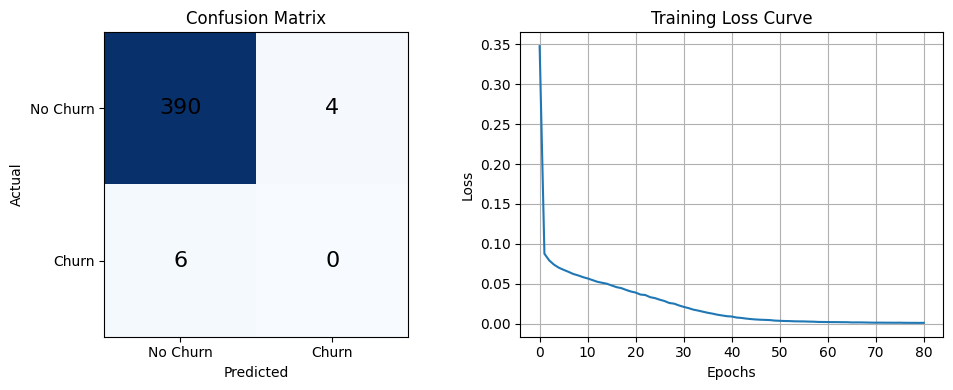

Saved: evaluation_outputs.png
Done! Check your results/ folder.


In [20]:
# ============================================================
# Save results to files
# ============================================================
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, log_loss, roc_auc_score

os.makedirs('results', exist_ok=True)

# --- FILE 1: model_comparison_table.csv ---
# (Using results from Task 5 experiments)

comparison_df.to_csv('results/model_comparison_table.csv', index=False)
print("Saved: model_comparison_table.csv")


# --- FILE 2: evaluation_outputs.png ---

y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)
cm = confusion_matrix(y_test, y_test_pred)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Plot 1: Confusion Matrix
axes[0].imshow(cm, cmap='Blues')
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['No Churn', 'Churn'])
axes[0].set_yticklabels(['No Churn', 'Churn'])
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=16)

# Plot 2: Loss Curve
axes[1].plot(model.loss_curve_)
axes[1].set_title('Training Loss Curve')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].grid(True)

plt.tight_layout()
plt.savefig('results/evaluation_outputs.png')
plt.show()
print("Saved: evaluation_outputs.png")

print("Done! Check your results/ folder.")